In [1]:
import psutil
import platform
import os
env_name = os.environ.get('CONDA_DEFAULT_ENV')
print("当前 conda 环境名：", env_name)
print(platform.system()) # 操作系统名称
print(platform.release()) # 操作系统版本
print(platform.machine()) # 计算机架构
print(platform.processor()) # 处理器类型
# CPU 信息
print(psutil.cpu_count()) # CPU 核数
print(psutil.cpu_freq()) # CPU 频率
# 内存信息
print(psutil.virtual_memory()) # 内存总量、可用内存、已用内存等

当前 conda 环境名： database001
Windows
11
AMD64
Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
20
scpufreq(current=2400.0, min=0.0, max=2400.0)
svmem(total=16891371520, available=1044340736, percent=93.8, used=15847030784, free=1044340736)


# 2.1
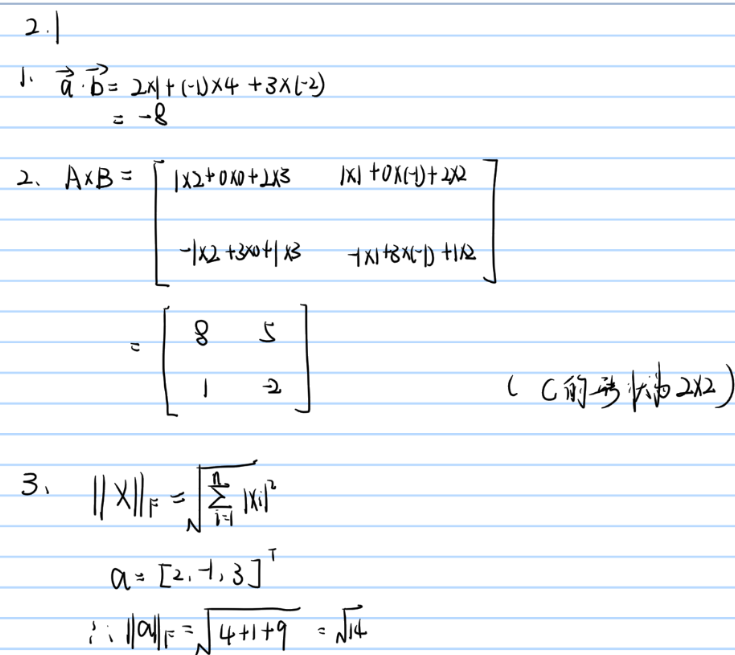

# 编程题 2.2


2.2 编程题
使用 NumPy（或 MXNet / PyTorch/TensorFlow）完成以下任务：
1. 创建一个形状为 3 × 4 的随机矩阵 X，元素服从标准正态分布
2. 创建一个形状为 4 × 2 的全 1 矩阵 Y 。
3. 计算矩阵乘法 Z = X × Y 。
4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素。
5. 计算 Z 的 Frobenius 范数。

In [3]:
#.随机矩阵X
#np.random.seed(42)  #固定输出
X = np.random.randn(3, 4)
print("1. 矩阵X (3×4):")
print(X)

# 2. 创建4×2全1矩阵Y
# '1.'相当于是1.0的缩写  np.ones () 默认生成小数 1.0  显示为 1.
Y = np.ones((4, 2))
print("\n2. 矩阵Y (4×2):")
print(Y)

#3.矩阵乘法Z = X × Y
Z = np.dot(X, Y)
print("\n3. 矩阵Z = X × Y (3×2):")
print(Z)

# 4.输出特定元素
print(f"\n4. Z的第一行第二列元素: {Z[0, 1]:.4f}")
print(f"   Z的第二行所有元素: {Z[1, :]}")

# 5.Z的Frobenius范数
Z_frobenius = np.linalg.norm(Z)
print(f"\n5. Z的Frobenius范数: {Z_frobenius:.4f}")

1. 矩阵X (3×4):
[[ 1.14689662 -0.3928256   1.42337091  0.16200118]
 [ 0.06571806  0.76726907 -0.97329101 -0.44527092]
 [ 2.60309621 -0.12232532 -0.70042906  1.22484418]]

2. 矩阵Y (4×2):
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

3. 矩阵Z = X × Y (3×2):
[[ 2.33944311  2.33944311]
 [-0.58557479 -0.58557479]
 [ 3.00518601  3.00518601]]

4. Z的第一行第二列元素: 2.3394
   Z的第二行所有元素: [-0.58557479 -0.58557479]

5. Z的Frobenius范数: 5.4492


# 3.1
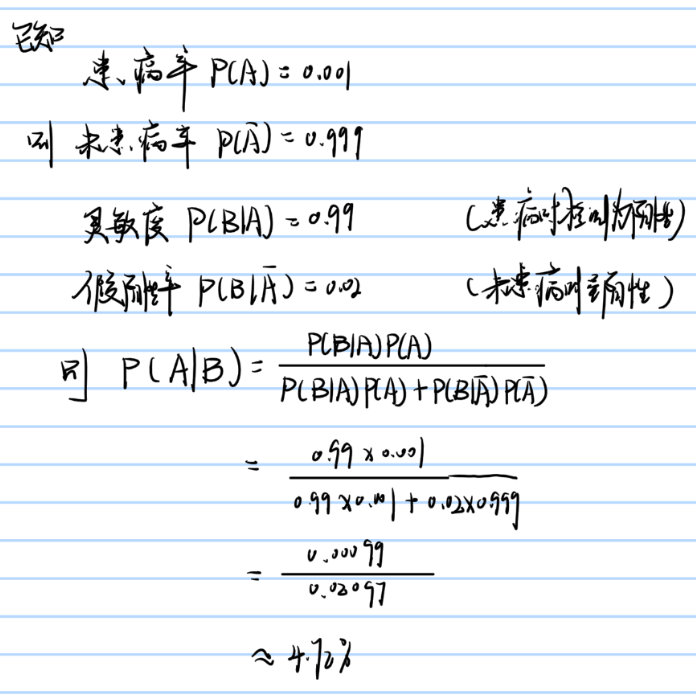

# 3.2 编程题
用 Python 模拟中心极限定理：
1. 生成 n = 10000 个服从均匀分布 U(0, 1) 的随机变量，重复 m = 1000
次，每次计算这 n 个变量的均值。
2. 绘制这 1000 个均值的直方图，并叠加理论正态分布的概率密度曲线。
3. 计算这些均值的实际方差。

3. 均值的实际方差: 0.000009
   理论方差(1/(12*10000)): 0.000008


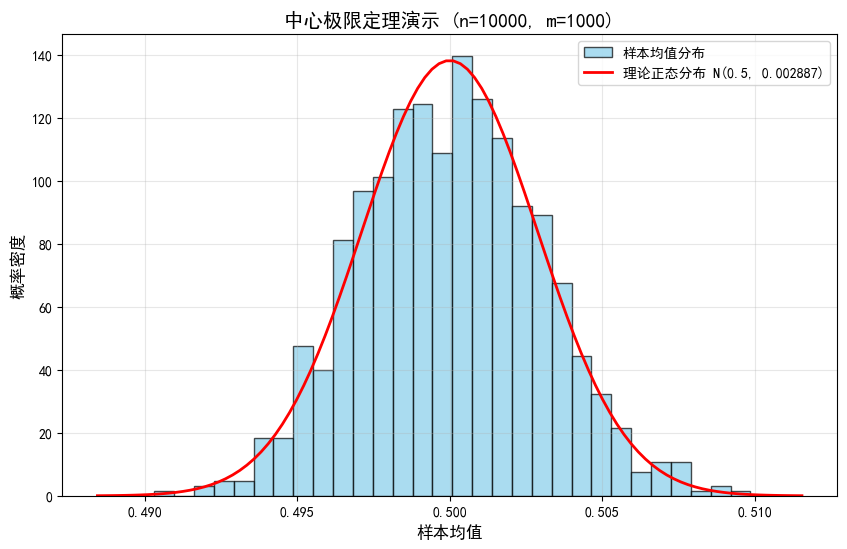

In [5]:
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["font.family"] = ["SimHei", "DejaVu Sans"]  # 中文
plt.rcParams["axes.unicode_minus"] = False  # 负号

# 设置参数
n = 10000  # 每次抽取的样本数
m = 1000   # 重复次数

# 生成m次均值
#np.random.seed(42)////固不固定得出的结果相同
sample_means = np.zeros(m)

for i in range(m):
    # 生成n个U(0,1)随机变量并计算均值
    samples = np.random.uniform(0, 1, n)
    sample_means[i] = np.mean(samples)

# 计算实际方差
actual_variance = np.var(sample_means)
print(f"3. 均值的实际方差: {actual_variance:.6f}")
print(f"   理论方差(1/(12*{n})): {1/(12*n):.6f}")

# 绘制直方图和理论正态分布曲线
plt.figure(figsize=(10, 6))
plt.hist(sample_means, bins=30, density=True, alpha=0.7, 
         color='skyblue', edgecolor='black', label='样本均值分布')

# 叠加理论正态分布曲线
mu = 0.5  # U(0,1)的期望
sigma = np.sqrt(1/(12*n))  # 理论标准差
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 
         'r-', linewidth=2, label=f'理论正态分布 N(0.5, {sigma:.6f})')

plt.xlabel('样本均值', fontsize=12)
plt.ylabel('概率密度', fontsize=12)
plt.title(f'中心极限定理演示 (n={n}, m={m})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4.1

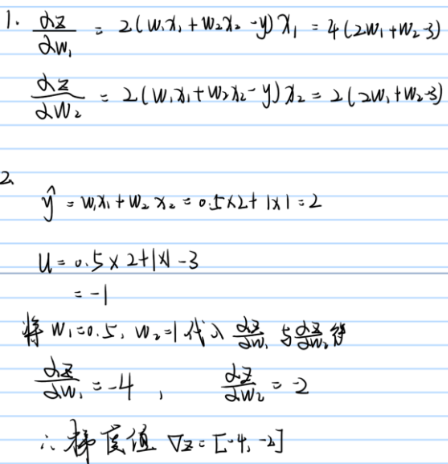

In [6]:
#已知条件
x1, x2, y = 2, 1, 3
w1, w2 = 0.5, 1

#1.表达式
print(f"1. 梯度表达式:")
print(f"   ∂z/∂w1 = 2*(w1*x1 + w2*x2 - y) * x1")
print(f"   ∂z/∂w2 = 2*(w1*x1 + w2*x2 - y) * x2")

#2.计算梯度
#预测值
prediction = w1*x1 + w2*x2
#误差
error = prediction - y
#梯度
grad_w1 = 2 * error * x1
grad_w2 = 2 * error * x2
print(f"   \n2.预测值: {prediction}")
print(f"   误差: {error}")
print(f"   ∂z/∂w1 = {grad_w1}")
print(f"   ∂z/∂w2 = {grad_w2}")

1. 梯度表达式:
   ∂z/∂w1 = 2*(w1*x1 + w2*x2 - y) * x1
   ∂z/∂w2 = 2*(w1*x1 + w2*x2 - y) * x2
   
2.预测值: 2.0
   误差: -1.0
   ∂z/∂w1 = -4.0
   ∂z/∂w2 = -2.0


# 4.2 编程题
手动实现一个简单计算图的反向传播：
1. 定义前向计算：输入 x，经过 a = x · w1，b = a + w2，输出 L = b
2。
2. 给定 x = 2, w1 = 1.5, w2 = 0.5，计算前向结果。
3. 手动（按链式法则）计算损失 L 对 w1, w2 的梯度，并验证与自动微分
工具（如 torch.autograd）的结果是否一致。

In [7]:
import torch
# 1.定义前向计算
def forward(x, w1, w2):
    a = x * w1
    b = a + w2
    L = b ** 2
    return L, a, b
# 2.给定输入 计算前向结果
x = 2.0
w1 = 1.5
w2 = 0.5
L, a, b = forward(x, w1, w2)
print(f"2. 前向计算结果:")
print(f"   a = x * w1 = {x} * {w1} = {a}")
print(f"   b = a + w2 = {a} + {w2} = {b}")
print(f"   L = b^2 = {b}^2 = {L}")
grad_w1_manual = 2 * b * x
grad_w2_manual = 2 * b

print(f"   ∂L/∂w1 = 2*b*x = 2*{b}*{x} = {grad_w1_manual}")
print(f"   ∂L/∂w2 = 2*b = 2*{b} = {grad_w2_manual}")


2. 前向计算结果:
   a = x * w1 = 2.0 * 1.5 = 3.0
   b = a + w2 = 3.0 + 0.5 = 3.5
   L = b^2 = 3.5^2 = 12.25
   ∂L/∂w1 = 2*b*x = 2*3.5*2.0 = 14.0
   ∂L/∂w2 = 2*b = 2*3.5 = 7.0


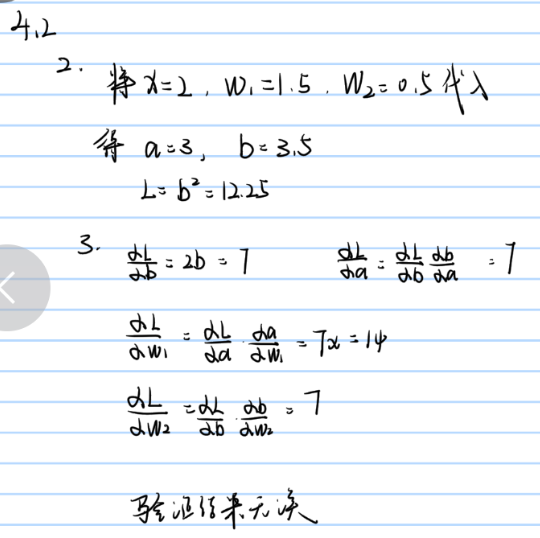

# 5.1
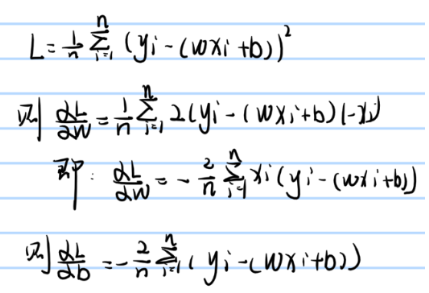

# 5.2 编程题
从零实现 softmax 回归对手写数字（MNIST）进行分类：
1. 使用 sklearn.datasets.load_digits() 或自己加载 MNIST 子集。
2. 将图像展平为向量，对标签进行 one‑hot 编码。
3. 实现 softmax 函数、交叉熵损失函数。
4. 使用小批量随机梯度下降（批量大小 32，学习率 0.1）训练模型 50 个
epoch。
5. 输出测试集上的准确率。

In [8]:
!pip install scikit-learn

In [9]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder


#1.数据加载 预处理
np.random.seed(42)  
digits = load_digits()
X = digits.data  #  (1797, 64)
y = digits.target.reshape(-1, 1)  # 转为列向量

# 划分训练集测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# 归一化
X_train = X_train / 16.0
X_test = X_test / 16.0
# One-hot 编码
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train)
y_test_onehot = encoder.transform(y_test)

print(f"训练集大小: {X_train.shape[0]}, 测试集大小: {X_test.shape[0]}")
print(f"特征维度: {X_train.shape[1]}")

# 2.核心函数
def softmax(z):
    """数值稳定的 softmax 函数"""
    z_stable = z - np.max(z, axis=1, keepdims=True)# 防止指数爆炸
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    """交叉熵损失函数"""
    n_samples = y_true.shape[0]
    # 防止 log(0)
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    log_probs = -np.log(y_pred)
    loss = np.sum(y_true * log_probs) / n_samples
    return loss

# 3.参数初始化
n_features = X_train.shape[1]
n_classes = 10

W = np.random.randn(n_features, n_classes) * 0.01
b = np.zeros((1, n_classes))

# 4.模型训练
batch_size = 32
learning_rate = 0.1
n_epochs = 50

train_loss_history = []
test_acc_history = []

print("\n开始训练")
for epoch in range(n_epochs):
    
    indices = np.random.permutation(X_train.shape[0])
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    epoch_loss = 0
    n_batches = 0
    
    # 小批量梯度下降
    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        #前向
        z = X_batch @ W + b
        y_pred = softmax(z)
        
        #损失
        loss = cross_entropy_loss(y_pred, y_batch)
        epoch_loss += loss
        n_batches += 1
        
        #反向
        m = X_batch.shape[0]
        dz = (y_pred - y_batch) / m
        dW = X_batch.T @ dz
        db = np.sum(dz, axis=0, keepdims=True)
        
        #更新参数
        W -= learning_rate * dW
        b -= learning_rate * db
    
    #训练损失
    avg_loss = epoch_loss / n_batches
    train_loss_history.append(avg_loss)
    
    #准确率
    z_test = X_test @ W + b
    y_test_pred = softmax(z_test)
    test_pred_labels = np.argmax(y_test_pred, axis=1)
    test_true_labels = np.argmax(y_test_onehot, axis=1)
    test_acc = np.mean(test_pred_labels == test_true_labels)
    test_acc_history.append(test_acc)
    
    # 打印训练信息
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}/{n_epochs} | "
              f"Loss: {avg_loss:.4f} | "
              f"Test Acc: {test_acc:.4f}")

print(f"\n训练完成")
print(f"最终测试集准确率: {test_acc_history[-1]:.4f}")
print(f"最佳测试集准确率: {max(test_acc_history):.4f} (Epoch {test_acc_history.index(max(test_acc_history))+1})")

训练集大小: 1437, 测试集大小: 360
特征维度: 64

开始训练
Epoch 10/50 | Loss: 0.4573 | Test Acc: 0.9222
Epoch 20/50 | Loss: 0.3004 | Test Acc: 0.9417
Epoch 30/50 | Loss: 0.2404 | Test Acc: 0.9500
Epoch 40/50 | Loss: 0.2078 | Test Acc: 0.9528
Epoch 50/50 | Loss: 0.1859 | Test Acc: 0.9583

训练完成
最终测试集准确率: 0.9583
最佳测试集准确率: 0.9583 (Epoch 44)


# 6.1
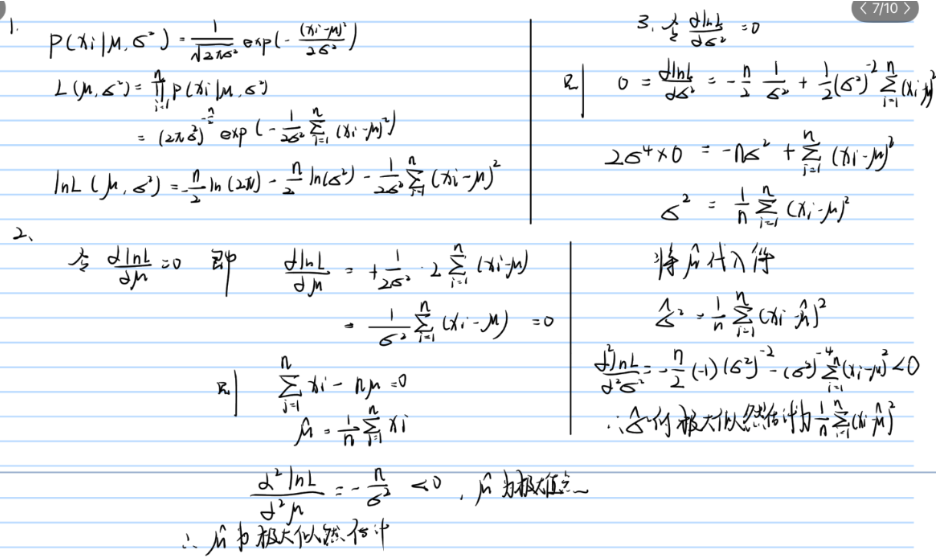

# 6.2 编程题
实现二分类逻辑回归模型（不使用深度学习框架的高阶 API）：
1. 生成两类线性可分的数据：每类 200 个样本，特征维度为 2。
2. 定义 sigmoid 函数和二元交叉熵损失。
3. 使用梯度下降法（学习率 0.1，迭代 1000 次）学习参数 w, b。
4. 绘制决策边界，并计算模型在测试集（新生成 100 个样本）上的分类
准确率。

训练集大小: 400 样本
测试集大小: 100 样本

===== 开始训练 =====
Iteration  200/1000 | Loss: 0.2344 | Train Acc: 0.9575
Iteration  400/1000 | Loss: 0.1530 | Train Acc: 0.9875
Iteration  600/1000 | Loss: 0.1170 | Train Acc: 0.9900
Iteration  800/1000 | Loss: 0.0967 | Train Acc: 0.9900
Iteration 1000/1000 | Loss: 0.0837 | Train Acc: 0.9925

===== 训练完成 =====
权重 w: [0.8088, 0.4356]
偏置 b: -5.6283
决策边界方程: 0.8088*x1 + 0.4356*x2 + -5.6283 = 0

测试集准确率: 0.9900 (99.00%)


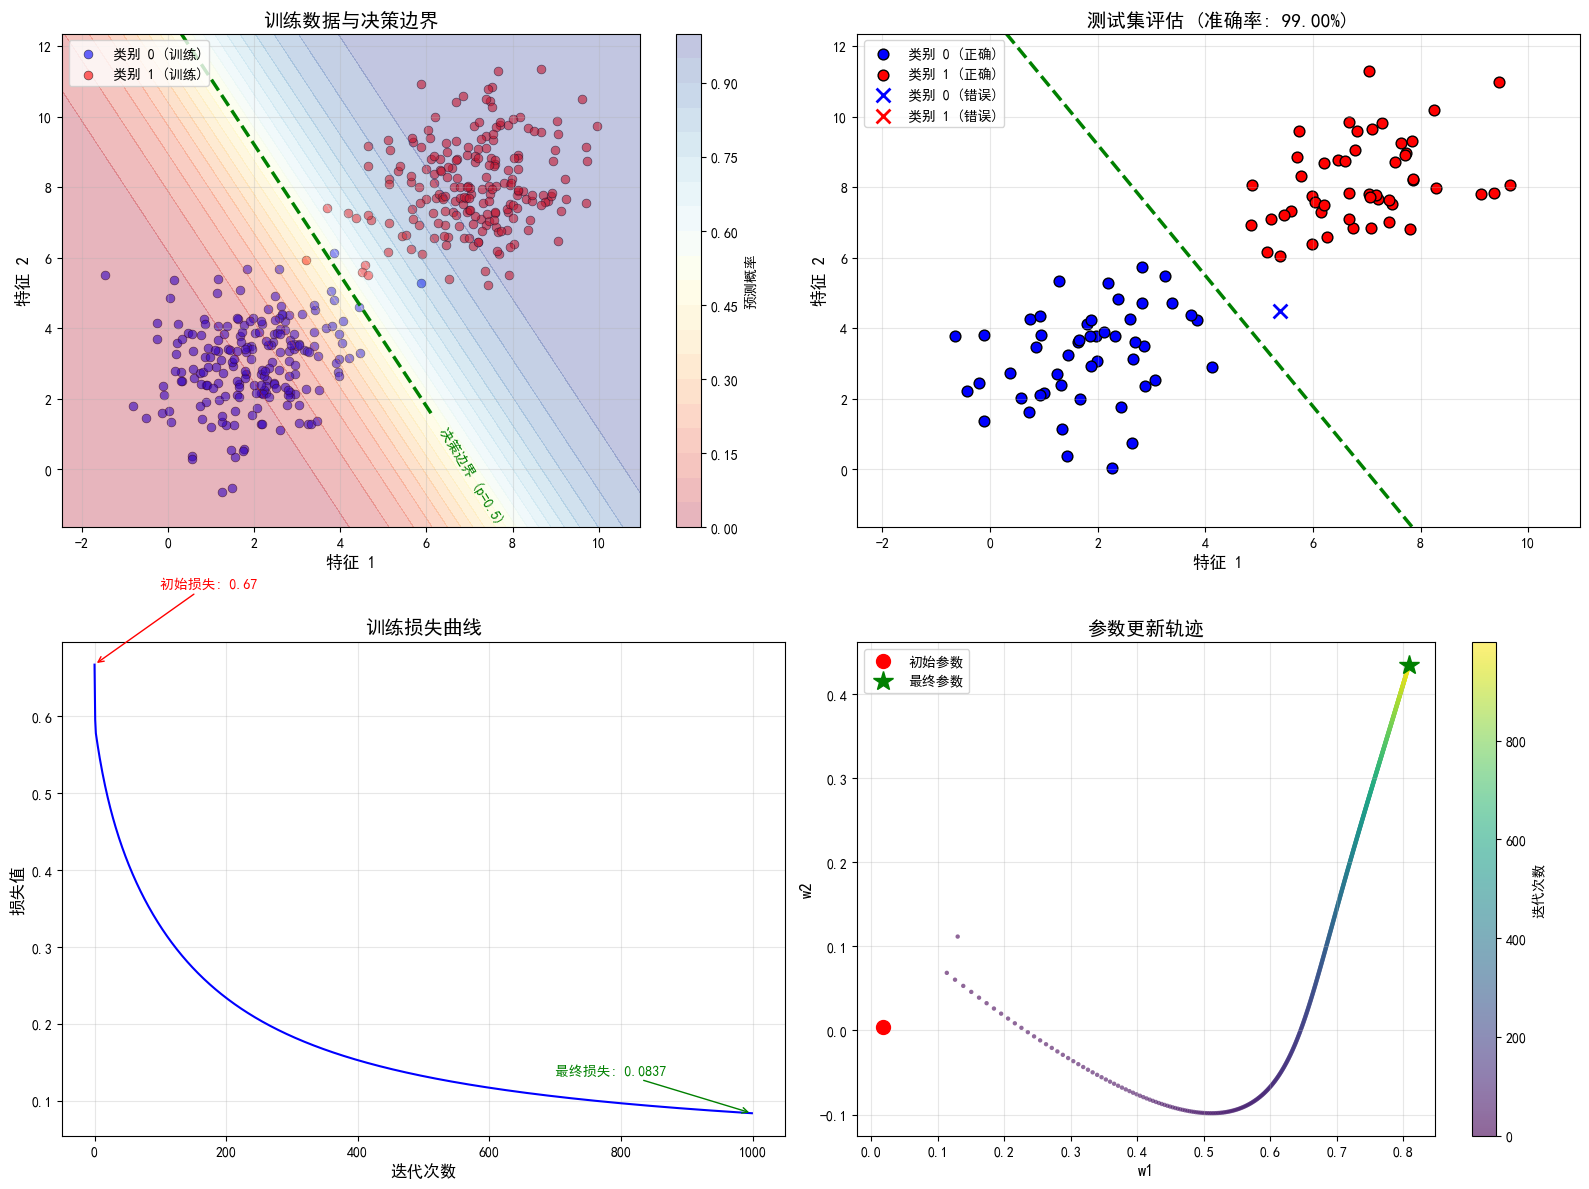

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

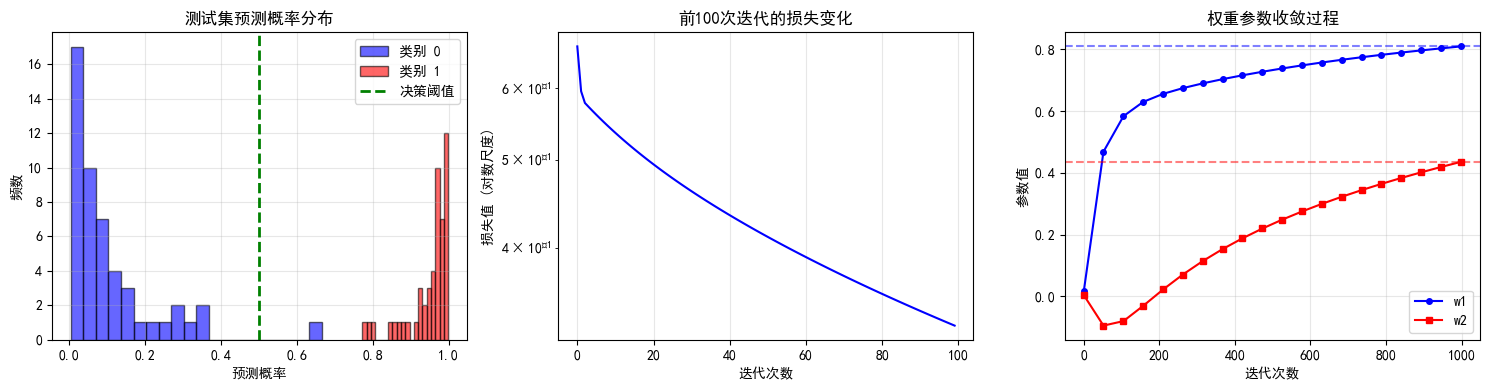

正确分类的测试样本: 99/100
错误分类的测试样本: 1/100

预测示例
样本 1: 特征=(1.68, 2.00), 真实标签=0, 预测概率=0.0323, 预测标签=0
样本 2: 特征=(7.52, 8.72), 真实标签=1, 预测概率=0.9860, 预测标签=1
样本 3: 特征=(4.13, 2.90), 真实标签=0, 预测概率=0.2643, 预测标签=0
样本 4: 特征=(5.59, 7.31), 真实标签=1, 预测概率=0.8889, 预测标签=1
样本 5: 特征=(7.85, 8.19), 真实标签=1, 预测概率=0.9865, 预测标签=1


In [10]:
import numpy as np
import matplotlib.pyplot as plt


# 1.两类线性可分的数据

np.random.seed(42)  
# 类别 0：200个样本，以 (2, 3) 为中心
n_samples_per_class = 200
mean0 = np.array([2, 3])
cov0 = np.array([[1.5, 0.3], [0.3, 1.5]])
X0 = np.random.multivariate_normal(mean0, cov0, n_samples_per_class)
y0 = np.zeros((n_samples_per_class, 1))

# 类别 1：200个样本，以 (7, 8) 为中心
mean1 = np.array([7, 8])
cov1 = np.array([[1.5, 0.3], [0.3, 1.5]])
X1 = np.random.multivariate_normal(mean1, cov1, n_samples_per_class)
y1 = np.ones((n_samples_per_class, 1))

# 合并训练数据
X_train = np.vstack([X0, X1])  # (400, 2)
y_train = np.vstack([y0, y1])  # (400, 1)

# 测试集：每类50个
np.random.seed(24)  
n_test_per_class = 50
X_test0 = np.random.multivariate_normal(mean0, cov0, n_test_per_class)
y_test0 = np.zeros((n_test_per_class, 1))
X_test1 = np.random.multivariate_normal(mean1, cov1, n_test_per_class)
y_test1 = np.ones((n_test_per_class, 1))

X_test = np.vstack([X_test0, X_test1])
y_test = np.vstack([y_test0, y_test1])

print(f"训练集大小: {X_train.shape[0]} 样本")
print(f"测试集大小: {X_test.shape[0]} 样本")

# 2. 定义 sigmoid 函数和二元交叉熵损失

def sigmoid(z):
    """Sigmoid 激活函数（带数值稳定性处理）"""
    z = np.clip(z, -500, 500)  # 防止 exp 溢出
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    """二元交叉熵损失函数"""
    n = len(y_true)
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)  # 防止 log(0)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

# 3. 梯度下降
# 初始化
np.random.seed(0)
w = np.random.randn(2, 1) * 0.01  # 小随机值初始化，打破对称性
b = 0.0

# 超参
learning_rate = 0.1
n_iterations = 1000

loss_history = []
w_history = []
b_history = []

print("\n===== 开始训练 =====")
for iteration in range(n_iterations):
    # 前向
    z = X_train @ w + b
    y_pred = sigmoid(z)
    
    # 损失
    loss = binary_cross_entropy(y_train, y_pred)
    loss_history.append(loss)
 
    w_history.append(w.copy())
    b_history.append(b)
    
    # 反向传播：计算梯度
    m = len(y_train)
    dz = (y_pred - y_train) / m  # sigmoid + BCE 的梯度简洁形式
    dw = X_train.T @ dz
    db = np.sum(dz)
    
    # 更新参数
    w -= learning_rate * dw
    b -= learning_rate * db
    
    # 每 200 次迭代打印信息
    if (iteration + 1) % 200 == 0:
        # 准确率
        y_pred_labels = (y_pred >= 0.5).astype(int)
        train_acc = np.mean(y_pred_labels == y_train)
        print(f"Iteration {iteration+1:4d}/{n_iterations} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f}")

print(f"\n===== 训练完成 =====")
print(f"权重 w: [{w[0,0]:.4f}, {w[1,0]:.4f}]")
print(f"偏置 b: {b:.4f}")
print(f"决策边界方程: {w[0,0]:.4f}*x1 + {w[1,0]:.4f}*x2 + {b:.4f} = 0")

# 4. 测试集评估

z_test = X_test @ w + b
y_test_pred_prob = sigmoid(z_test)
y_test_pred = (y_test_pred_prob >= 0.5).astype(int)
test_accuracy = np.mean(y_test_pred == y_test)

print(f"\n测试集准确率: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# 5. 可视化
fig = plt.figure(figsize=(16, 12))

# 训练数据  决策边界 概率热力图 
ax1 = plt.subplot(2, 2, 1)

# 绘制训练数据
ax1.scatter(X_train[y_train.flatten()==0, 0], X_train[y_train.flatten()==0, 1], 
           c='blue', alpha=0.6, s=40, label='类别 0 (训练)', edgecolors='k', linewidth=0.5)
ax1.scatter(X_train[y_train.flatten()==1, 0], X_train[y_train.flatten()==1, 1], 
           c='red', alpha=0.6, s=40, label='类别 1 (训练)', edgecolors='k', linewidth=0.5)

x1_min, x1_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
x2_min, x2_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                       np.linspace(x2_min, x2_max, 200))

# 预测网格点的概率
X_grid = np.c_[xx1.ravel(), xx2.ravel()]
z_grid = sigmoid(X_grid @ w + b)
z_grid = z_grid.reshape(xx1.shape)

# 绘热力图
contourf = ax1.contourf(xx1, xx2, z_grid, levels=20, alpha=0.3, cmap='RdYlBu')
plt.colorbar(contourf, ax=ax1, label='预测概率')

# 决策边界
contour = ax1.contour(xx1, xx2, z_grid, levels=[0.5], colors='green', linewidths=2.5, linestyles='--')
ax1.clabel(contour, fmt='决策边界 (p=0.5)', fontsize=10)

ax1.set_xlabel('特征 1', fontsize=12)
ax1.set_ylabel('特征 2', fontsize=12)
ax1.set_title('训练数据与决策边界', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 测试集评估 
ax2 = plt.subplot(2, 2, 2)

# 正确分类的测试样本
correct = y_test_pred.flatten() == y_test.flatten()
incorrect = ~correct

ax2.scatter(X_test[correct & (y_test.flatten()==0), 0], 
           X_test[correct & (y_test.flatten()==0), 1], 
           c='blue', marker='o', s=60, label='类别 0 (正确)', edgecolors='k')
ax2.scatter(X_test[correct & (y_test.flatten()==1), 0], 
           X_test[correct & (y_test.flatten()==1), 1], 
           c='red', marker='o', s=60, label='类别 1 (正确)', edgecolors='k')

# 错误分类的测试样本
if np.sum(incorrect) > 0:
    ax2.scatter(X_test[incorrect & (y_test.flatten()==0), 0], 
               X_test[incorrect & (y_test.flatten()==0), 1], 
               c='blue', marker='x', s=100, label='类别 0 (错误)', linewidths=2)
    ax2.scatter(X_test[incorrect & (y_test.flatten()==1), 0], 
               X_test[incorrect & (y_test.flatten()==1), 1], 
               c='red', marker='x', s=100, label='类别 1 (错误)', linewidths=2)

# 决策边界
ax2.contour(xx1, xx2, z_grid, levels=[0.5], colors='green', linewidths=2.5, linestyles='--')

ax2.set_xlabel('特征 1', fontsize=12)
ax2.set_ylabel('特征 2', fontsize=12)
ax2.set_title(f'测试集评估 (准确率: {test_accuracy:.2%})', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

#损失曲线 
ax3 = plt.subplot(2, 2, 3)
ax3.plot(range(n_iterations), loss_history, 'b-', linewidth=1.5)
ax3.set_xlabel('迭代次数', fontsize=12)
ax3.set_ylabel('损失值', fontsize=12)
ax3.set_title('训练损失曲线', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

ax3.annotate(f'初始损失: {loss_history[0]:.2f}', 
            xy=(0, loss_history[0]), xytext=(100, loss_history[0] + 0.1),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')
ax3.annotate(f'最终损失: {loss_history[-1]:.4f}', 
            xy=(n_iterations-1, loss_history[-1]), xytext=(n_iterations-300, loss_history[-1] + 0.05),
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=10, color='green')

# 参数更新轨迹
ax4 = plt.subplot(2, 2, 4)

# 提取参数历史
w1_history = [w[0,0] for w in w_history]
w2_history = [w[1,0] for w in w_history]

# 绘制参数轨迹
scatter = ax4.scatter(w1_history, w2_history, c=range(n_iterations), 
                     cmap='viridis', s=10, alpha=0.6, edgecolors='none')
ax4.plot(w1_history[0], w2_history[0], 'ro', markersize=10, label='初始参数')
ax4.plot(w1_history[-1], w2_history[-1], 'g*', markersize=15, label='最终参数')

plt.colorbar(scatter, ax=ax4, label='迭代次数')
ax4.set_xlabel('w1', fontsize=12)
ax4.set_ylabel('w2', fontsize=12)
ax4.set_title('参数更新轨迹', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig2, axes = plt.subplots(1, 3, figsize=(15, 4))

# 预测概率分布
axes[0].hist(y_test_pred_prob[y_test.flatten()==0], bins=20, alpha=0.6, 
            color='blue', label='类别 0', edgecolor='black')
axes[0].hist(y_test_pred_prob[y_test.flatten()==1], bins=20, alpha=0.6, 
            color='red', label='类别 1', edgecolor='black')
axes[0].axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='决策阈值')
axes[0].set_xlabel('预测概率')
axes[0].set_ylabel('频数')
axes[0].set_title('测试集预测概率分布')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 前100次迭代的损失（对数）
axes[1].semilogy(range(100), loss_history[:100], 'b-', linewidth=1.5)
axes[1].set_xlabel('迭代次数')
axes[1].set_ylabel('损失值 (对数尺度)')
axes[1].set_title('前100次迭代的损失变化')
axes[1].grid(True, alpha=0.3)

# 参数收敛过程
iterations_to_plot = np.linspace(0, n_iterations-1, 20, dtype=int)
w1_vals = [w1_history[i] for i in iterations_to_plot]
w2_vals = [w2_history[i] for i in iterations_to_plot]

axes[2].plot(iterations_to_plot, w1_vals, 'b-o', label='w1', markersize=4)
axes[2].plot(iterations_to_plot, w2_vals, 'r-s', label='w2', markersize=4)
axes[2].axhline(y=w1_history[-1], color='blue', linestyle='--', alpha=0.5)
axes[2].axhline(y=w2_history[-1], color='red', linestyle='--', alpha=0.5)
axes[2].set_xlabel('迭代次数')
axes[2].set_ylabel('参数值')
axes[2].set_title('权重参数收敛过程')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"正确分类的测试样本: {np.sum(correct)}/{len(y_test)}")
print(f"错误分类的测试样本: {np.sum(incorrect)}/{len(y_test)}")


print(f"\n预测示例")
indices_to_show = np.random.choice(len(X_test), min(5, len(X_test)), replace=False)
for i, idx in enumerate(indices_to_show):
    print(f"样本 {i+1}: 特征=({X_test[idx,0]:.2f}, {X_test[idx,1]:.2f}), "
          f"真实标签={y_test[idx,0]:.0f}, "
          f"预测概率={y_test_pred_prob[idx,0]:.4f}, "
          f"预测标签={y_test_pred[idx,0]}")